In [112]:
import numpy as np
import sisl
from sisl import MonkhorstPack
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
import plotly.graph_objects as go
from sisl import viz
from sisl.viz.processors.math import normalize
from time import time

from scipy.spatial import cKDTree

from ase.visualize import view, plot


# Decorator functions

In [77]:
def timeit(func):
    """Decorator to time function call."""
    def wrapper(*args, **kwargs):
        initial_time = time()
        result = func(*args, **kwargs)
        final_time = time()
        func_args = {}
        if (args is None) or (len(args) == 0):
            func_args["width"] = kwargs["width"]
            func_args["length"] = kwargs["length"]
        else:
            func_args["width"] = args[0]
            func_args["length"] = args[1]
            
        print(f"func '{func.__name__}' with args : {func_args}  ran in {final_time - initial_time:.3f} s")
        return result
    return wrapper

def count_removals(func):
    """Decorator to count number of atoms before and after removing overlaps."""
    def wrapper(*args, **kwargs):
        initial_count = len(args[0])
        result = func(*args, **kwargs)
        final_count = len(result)
        print(f"       Initial number of atoms: {initial_count}")
        print(f" Atoms after removing overlaps: {final_count}")
        return result
    return wrapper

In [78]:
def _parse_E_range(**kwargs):
    """
    Parsing energy value range from keywords
    """
    E = kwargs.get("E", None)
    size = kwargs.get("size", 400)
    Emax = kwargs.get("Emax", 4)
    Emin = kwargs.get("Emin", -4)
    if isinstance(E, (int, float)):
        return np.linspace(-E, E, size)
    elif E is None:
        return np.linspace(Emin, Emax, size)
    else:
        return E

# Generate structure

In [ ]:
## Helper functions for tiling
# ---------------------------
# Geometry helper functions
# ---------------------------

def get_coordinates(structure):
    """Return atomic coordinates as numpy array."""
    if isinstance(structure, sisl.Geometry):
        return structure.xyz
    elif isinstance(structure, np.ndarray):
        return structure
    else:
        raise TypeError("Input must be a sisl.Geometry or numpy.ndarray.")
    
def find_nearest_atoms(structure, center, n=6):
    """Return indices of n atoms closest to a given center."""
    coords = get_coordinates(structure)
    distances = np.linalg.norm(coords - center, axis=1)
    return np.argsort(distances)[:n]


def guess_hexagon_center(structure):
    """
    Try to locate the center of a hexagon near the geometric center.
    If not found, iteratively shift the center guess.
    """
    BOND = 1.42
    NN_2_DIST = 2 * BOND * np.cos(np.deg2rad(30))  # distance between two second-nearest neighbors in graphene
    RTOL = 0.05  # relative tolerance for checking if center lies on bonds
    coords = get_coordinates(structure)
    center = coords.mean(axis=0) 
    
    atom_idx = find_nearest_atoms(structure, center, n=6)
    hex_coords = coords[atom_idx]
    center = hex_coords.mean(axis=0)
    atom1, atom2 = hex_coords[[0, 1]]
    if np.isclose(atom1[1], atom2[1], rtol=RTOL) and np.isclose(atom1[1], center[1], rtol=RTOL):
        print("Warning: The geometric center lies on bonds. Trying to shift the center by half atomic distance to 2. NN.")
        print(f"{'Atom 1':>20}:", atom1)
        print(f"{'Atom 2':>20}:", atom2)
        center += np.array([0, NN_2_DIST/2, 0])  # shift the center by half the distance to the 2nd NN
        print(f"{'New Center':>20}:", center)

    return atom_idx, center

In [303]:
# ---------------------------
# Structure generation
# ---------------------------

def find_overlap(structure, tol=0.1):
    """Find overlapping atoms in a structure."""
    coords = get_coordinates(structure)
    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=tol)  # find pairs of atoms closer than `tol`
    # print(f"{type(pairs) = }")
    return pairs

@count_removals
def delete_overlaps(structure, pairs=None):
    """Delete overlapping atoms from a structure."""
    if pairs is None:
        overlaps = find_overlap(structure)
    else:
        overlaps = pairs
    to_delete = set()
    for i, j in overlaps:
        to_delete.add(j)  # arbitrarily delete the second atom in each pair
    mask = np.array([i not in to_delete for i in range(len(structure))])
    return structure.sub(mask)

def set_index(overlaps, indexes):
    """Set atom indexes for each arm after removing overlaps."""
    # from copy import deepcopy
    # indexes_copy = deepcopy(indexes) # make a deep copy to avoid modifying the original
    
    # remove overlaps from arms 1 and 2
    for _, b in overlaps: 
        for arm in (1,2):
            if b in indexes[arm]:
                indexes[arm].remove(b)
    # for a, b in overlaps: # remove overlapping indexes from 
    #     if (b in indexes_copy[1]):
    #         indexes[1].remove(b)
    #     if (b in indexes_copy[2]):
    #         indexes[2].remove(b)
    arm0 = len(indexes[0])
    arm1 = len(indexes[1])
    arm2 = len(indexes[2])
    indexes[1] = list(range(arm0, arm0 + arm1))
    indexes[2] = list(range(arm0 + arm1, arm0 + arm1 + arm2))
    return indexes

def _init_indexes(nanoribbon):
    """Initialize atom indexes for each arm of the structure."""
    indexes = {} # dictionary to hold indexes for each arm
    total_atoms = len(nanoribbon) # total number of atoms in the structure
    print(f"Total number of atoms before removing overlaps: {total_atoms}")
    arm_length = total_atoms // 3 # assuming 3 arms of equal length
    indexes[0] = list(range(0, arm_length)) # indexes for the first arm
    indexes[1] = list(range(arm_length, 2 * arm_length)) # indexes for the second arm
    indexes[2] = list(range(2 * arm_length, total_atoms)) # indexes for the third arm
    return indexes

def make_nanoribbon(width, length, **kwargs):
    """Generate a graphene nanoribbon."""
    bond = kwargs.get('bond', 1.42)
    kind = kwargs.get('kind', 'armchair')
    vacuum = kwargs.get('vacuum', 3.0)
    ribbon = sisl.geom.graphene_nanoribbon(width=width, bond=bond, kind=kind, vacuum=vacuum)
    ribbon = ribbon.repeat(length, axis=0)
    ribbon.set_nsc((1,1,1)) # avoid periodicity in transport direction
    return ribbon

@timeit
def generate_structure(width=5, length=8, **kwargs):
    """Generate 3 rotated nanoribbons stacked around a central hexagon."""

    base = make_nanoribbon(width=width, length=length, **kwargs)
    
    # find central hexagon
    _, rotation_origin = guess_hexagon_center(base)
    
    # rotate and add ribbons
    structure = base.copy()
    for i in range(1, 3):
        angle = i * 60
        rotated = base.rotate(angle=angle, v=[0, 0, 1], origin=rotation_origin)
        structure += rotated
        
    overlaps = find_overlap(structure)
    
    if overlaps:
        indexes = _init_indexes(structure)
        indexes = set_index(overlaps, indexes)
        structure = delete_overlaps(structure)
        return structure, indexes
    else:
        return structure, indexes


Total number of atoms before removing overlaps: 24
Overlaps: set()


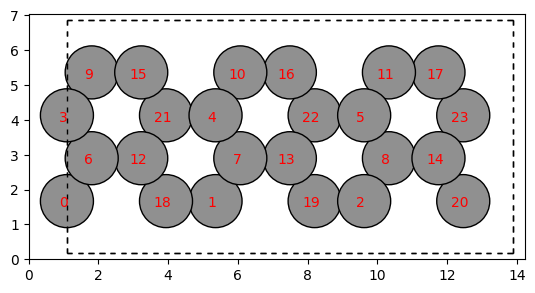

In [304]:
base = make_nanoribbon(4, 3, kind='armchair')
# base = base.repeat(2, axis=0)
test = base.copy()
# atom_index = _init_indexes(base)
# _, rotation_origin = guess_hexagon_center(base) 
# for i in range(1, 3):
#     rot_test = base.rotate(angle=i * 60, v=[0, 0, 1], origin=rotation_origin)
#     test += rot_test


indexes = _init_indexes(test)
overlaps = find_overlap(test)
print("Overlaps:", overlaps)
test.plot(axes="xy")

# view(test.to.ase(), viewer='x3d', )  # visualize with ASE viewer
ax = plot.plot_atoms(test.to.ase())  # visualize with ASE viewer

for a in range(len(test)):
    x, y, z = test[a]
    ax.annotate(str(a), (x+1, y), color='red', fontsize=10, ha="center")


# Construct Hamiltonian

In [305]:
def hamiltonian(structure, **kwargs):
    """Create a tight-binding Hamiltonian for a given structure."""
    r = kwargs.get("r", (0, 1.44)) # bond length in Angstrom
    t = kwargs.get("t", (0.0, -2.7)) # energy in eV
    H = sisl.Hamiltonian(structure)
    H.construct([r, t])
    if kwargs.get("finalize", False):
        H.finalize() # make hamiltonian sparse
    return H

In [306]:
@timeit
def compute_dos(width=5, length=5, **kwargs):
    E = kwargs.get("E", None)
    if E is None:
        E = _parse_E_range(**kwargs)
    k = kwargs.get("k", (0,0,0))
    graphene, _ = generate_structure(width=width, length=length)
    
    H = sisl.Hamiltonian(graphene)
    r = (0.1, 1.45)
    t = (0.0, -2.7)
    H.construct([r,t])
    es = H.eigenstate(k=k)
    return es.DOS(E)

# Plotting functions

## Plot geometry

In [307]:
# ---------------------------
# Plotting utilities
# ---------------------------

def plot_with_center(structure, **KWARGS):
    """Plot structure and highlight central hexagon + geometric center."""
    
    KWARGS.setdefault("axes", "xy")
    KWARGS.setdefault("bind_bonds_to_ats", True)
    atom_idx, hex_center = guess_hexagon_center(structure)
    # print(f"Hexagon atom indices: {atom_idx}")
    geom_center = structure.center()

    fig = structure.plot(**KWARGS)

    # highlight hexagon atoms
    fig.update_inputs(atoms_style={"color": "red", "atoms": atom_idx.tolist()})

    # add markers
    fig.add_trace(go.Scatter(
        x=[geom_center[0]], y=[geom_center[1]],
        mode="markers", marker=dict(size=10, color="red", symbol="x"),
        name="Geometric Center"
    ))
    
    fig.add_trace(go.Scatter(
        x=[hex_center[0]], y=[hex_center[1]],
        mode="markers", marker=dict(size=10, color="blue", symbol="circle"),
        name="Rotation Center"
    ))

    return fig

## plot dos

In [308]:
def plot_DOS(width=5, length=5, **kwargs):
    E = _parse_E_range(**kwargs)
    kwargs["E"] = E
    dos = compute_dos(width, length, **kwargs)
    # print("DOS computed! Plotting...", end="\r")
    ## plot figure
    plt.figure(figsize=(6,4))
    plt.plot(E, dos, color="black")
    plt.xlabel("Energy (eV)")
    plt.ylabel("DOS")
    plt.title(f"Graphene Nanoribbon DOS (width={width}, length={length})")
    plt.grid(True)
    plt.show()
    
def plot_center_pdos(structure, radius, **kwargs):
    if radius < 2:
        print(f"Radius too small ({radius}), using radius=2")
        radius=2
    center = structure.center() # xyz coordinate for center
    center_atoms = structure.close(center, radius) # C atom index within radius of center 
    E = _parse_E_range(**kwargs) # make list for energy values
    k = kwargs.get("k", (1,1,1)) # get k point to evaluate at, default: only Gamma (0,0,0)
    
    orb_groups = [
        {"atoms" : center_atoms}
    ] # group of atoms to use for plot
    
    # make hamiltonian
    H = sisl.Hamiltonian(structure)
    r = (0.1, 1.44)
    t = (0.0, -2.7)
    H.construct([r, t])
    
    # es = H.eigenstate(k=k) # eigenstates at k-point
    
    plot_range = kwargs.get("range", (E[0], E[-1]))
    size = kwargs.get("size", len(E))
    pdos_plot = H.plot.pdos(kgrid=k, data_Erange=(E[0], E[-1]), Erange=plot_range, nE=size)
    
    pdos_plot.update_inputs(groups=orb_groups)
    fig_title = f"PDOS,  r={radius:.1f} [Å]"
    pdos_plot.update_layout(title=dict(text=fig_title, font=dict(size=30)))
    pdos_plot.show()

# Generating structure and plotting PDOS

In [316]:
WIDTH = 15
LENGTH = 15
graphene, atom_index = generate_structure(width=WIDTH, length=LENGTH)

fig = plot_with_center(graphene)

if False:   
   num = 0
   for key in atom_index:
      current_num = len(atom_index[key])
      num += current_num
      print(f"{key} ({current_num}) : {atom_index[key]}")
   print(f"total atoms counted: {num}")
   
fig.update_inputs(atoms_style=[
   {"color": "red", "atoms": atom_index[0]}, 
   {"color": "blue", "atoms": atom_index[1]}, 
   {"color": "green", "atoms": atom_index[2]}
                               ])
fig.show()



Total number of atoms before removing overlaps: 1350
       Initial number of atoms: 1350
 Atoms after removing overlaps: 1014
func 'generate_structure' with args : {'width': 15, 'length': 15}  ran in 0.027 s


In [317]:
# check if any of the elements in each list from atom_index are in the other lists from atom_index
for a in range(len(graphene)):
    if a in atom_index[0]:
        if a in atom_index[1] or a in atom_index[2]:
            print(f"Atom {a} is in multiple arms!")
    if a in atom_index[1]:
        if a in atom_index[0] or a in atom_index[2]:
            print(f"Atom {a} is in multiple arms!")
    if a in atom_index[2]:
        if a in atom_index[0] or a in atom_index[1]:
            print(f"Atom {a} is in multiple arms!")
    # fig.add_annotation(text=str(a), x=x+1, y=y, showarrow=False, font=dict(color="black", size=10), align="center")

## Plot DOS

       Initial number of atoms: 1350
 Atoms after removing overlaps: 1014
func 'generate_structure' with args : {'width': 15, 'length': 15}  ran in 0.037 s
func 'compute_dos' with args : {'width': 15, 'length': 15}  ran in 2.981 s


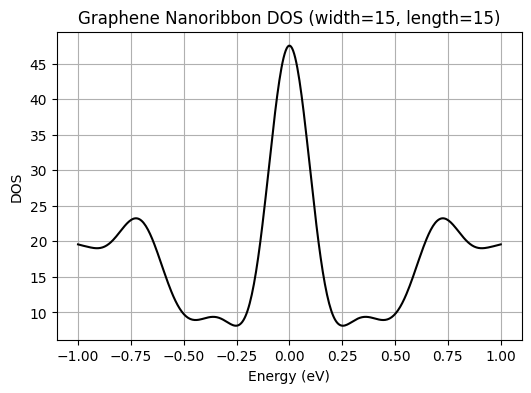

In [45]:
plot_DOS(width=WIDTH, length=LENGTH, E=1)   

In [46]:
interact(plot_DOS, 
         width=widgets.IntSlider(value=4, min=2, max=50, step=1, description="Width"),
         length=widgets.IntSlider(value=6, min=2, max=50, step=1, description="Length")); 

interactive(children=(IntSlider(value=4, description='Width', max=50, min=2), IntSlider(value=6, description='…

## Plot PDOS

### PDOS scaled atoms in geometry plot

In [ ]:
# from cell 11 - https://sisl.readthedocs.io/en/latest/tutorials/tutorial_es_1.html#Creating-the-electronic-structure 

K = (0,0,0)
H = sisl.Hamiltonian(graphene)
r = (0.1, 1.44)
t = (0.0, -2.7)
H.construct([r, t])


es = H.eigenstate(k=K)

E = np.linspace(-1, 1, 400)
dE = E[1] - E[0]

PDOS = es.PDOS(E).sum((0, 2)) * dE  # perform integration
fig = graphene.plot(axes="xy", atoms_style={"size": normalize(PDOS, 0, 1)})

geom_center = graphene.center()
center_fig = go.Scatter(
    x=[geom_center[0]], y=[geom_center[1]],
    mode="markers", marker=dict(size=10, color="red", symbol="x"),
    name="Geometric center"
)
fig.add_trace(center_fig)

fig.show()

# plt.scatter(graphene.xyz[:, 0], graphene.xyz[:, 1], 500 * PDOS);

## Plotting PDOS around geometric center
<!-- pdos_plot=H.plot.pdos(kgrid=[1, 1, 1],  data_Erange=(-4, 4), Erange=[-4, 4], nE=500)
plot.show() -->

### Static method

In [48]:
plot_center_pdos(graphene, 2)

### Interactive method

In [49]:
interact(plot_center_pdos,
         structure=widgets.fixed(graphene), 
         range=widgets.IntRangeSlider(value=[-3, 3], min=-4, max=4, step=1, description="Plot range"),
         radius=widgets.FloatSlider(value=5, min=2, max=50, step=.5, description="r [Å]"))

interactive(children=(FloatSlider(value=5.0, description='r [Å]', max=50.0, min=2.0, step=0.5), IntRangeSlider…

<function __main__.plot_center_pdos(structure, radius, **kwargs)>

## Band structure around center

In [50]:
## Does not quite work 

# H = sisl.Hamiltonian(graphene)
# r = (0.1, 1.44)
# t = (0.0, -2.7)

# H.construct([r,t])
# es = H.eigenstate(k=(0,0,0))

# E = _parse_E_range(E=4)
# # print(E[:10])

# PDOS = es.PDOS(E)

# band = sisl.BandStructure(
#     parent=H,
#     points=[[0, 0, 0], [0, 0.5, 0], [1 / 3, 2 / 3, 0], [0, 0, 0]],
#     divisions=400,
#     names=[r"Gamma", r"M", r"K", r"Gamma"],
# )


# # b_list = band.apply.list

# band.plot(Erange=[-1, 1])

## Visualize in ASE

In [51]:
from ase.visualize import view
view(graphene.to.ase())


<Popen: returncode: None args: ['/home/bastian/projects/QuantumTwistingMicro...>

In [52]:
SE = sisl.physics.SelfEnergy(H)

SE

In [17]:
SE = sisl.SelfEnergy(...)

sisl.__version__


'0.16.2'